In [1]:
import numpy as np


#### Linear Regression in Class

In [20]:
class Linear_Regression():

    # initiating the hyper parameters()
    def __init__(self, learning_rate, no_of_iterations):
        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations

    def fit(self, X, Y):

        # no of training examples and  no of features
        self.m, self.n = X.shape  #(30,1  || rows and columns)

        # initiating the weight and bias of our model
        self.w=np.zeros(self.n)
        self.b=0
        self.X=X
        self.Y=Y

        # ewquation of the model y=0x+0

        # implementing Gradient Descent
        for iteration in range(self.no_of_iterations):
            self.update_weights()

    def update_weights(self):

        Y_prediction = self.predict(self.X)   # go to predict function

        # calculate the gradients
        dw = -(2 * (self.X.T).dot(self.Y - Y_prediction))  / self.m
        # m is number of training examples

        db = -2 * np.sum(self.Y - Y_prediction) / self.m

        # update the weights
        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db


    def predict(self,X):
        return X.dot(self.w)+self.b


Work flow of the Linear Regression model:

Step 1: Set Learning Rate & Number of Iterations; Initiate Random weight and bias value.

Step 2: Build Linear Regression Equation. (y = wx + b)

Step 3: Find the "y pred" value for given x value for the corresponding weight & bias.

Step 4: Check the loss function for these parameter values. ( difference between "y pred" & "true y")

Step 5: Update the parameter values using Gradient Descent. (new weight & bias value)

Step 6: Step 3, 4, 5 are repeated till we get minimum loss function

Finally we will get the best model (best weight and bias value) as it has minimum loss function.

## Using Linear Regression For Prediction

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split



### Data Pre-Processing

In [5]:
# loading the data from csv file to panda dataframe
salary_data = pd.read_csv('salary_data.csv')

In [6]:
salary_data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [7]:
salary_data.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


In [9]:
salary_data.shape

(30, 2)

In [10]:
salary_data.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [11]:
salary_data.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [13]:
salary_data.notnull().sum()

YearsExperience    30
Salary             30
dtype: int64

### Splitting the feature and target

In [14]:
X = salary_data.iloc[:, :-1].values
Y = salary_data.iloc[:, 1].values

In [15]:
print(X)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]


In [16]:
print(Y)

[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


### splitting the data into train or test

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.33, random_state=2)

### training the linear regression model

In [33]:
model = Linear_Regression(learning_rate=0.02,no_of_iterations=1000)

In [34]:
model.fit(X_train, y_train)

In [35]:
# printing the parameter values  weight and bias

print('weight :', model.w[0])    # in my numpy array only got one feature
print('bias :', model.b )

weight : 9514.400999035135
bias : 23697.406507136307


## y = 9514 x + 23697

## salary= 9514(experience)+23697

## predict the salary value for test data

In [36]:
test_data_prediction = model.predict(X_test)

In [37]:
print(test_data_prediction)

[ 36066.12780588  34163.24760607  66512.21100279  58900.69020357
  91249.65360029  80783.81250135 101715.49469922  52240.60950424
  42726.20850521  88395.33330058]


### visualize predicted and actual values

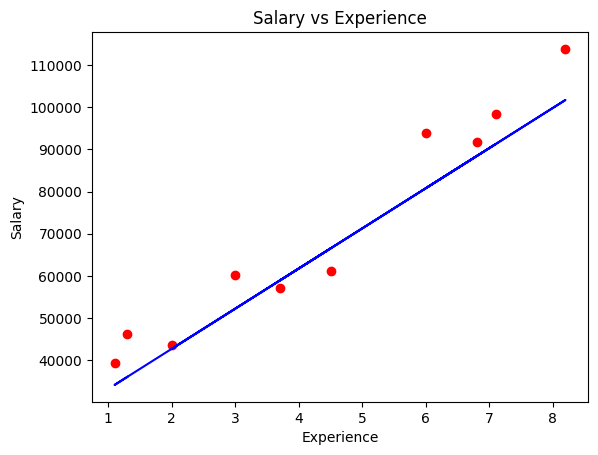

In [39]:
plt.scatter(X_test, y_test, color='red')
plt.plot(X_test, test_data_prediction, color='blue')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.show()